
# TCCM Homework:<br>**Data-Driven and ML Color Analysis of Portuguese Wines**

<div class="intro">
    
<p style="text-align: center"><img width="650px" src="https://github.com/rpoteau/pyPhysChem/blob/main/DS4B-CO2-images/vinho-verde-header.jpg?raw=1" style="margin-left:auto; margin-right:auto" id="img_vinho_verde"></p>
<br>

1. The purpose of this project is to **classify white **and** red** Portuguese Vinho Verde wines based on their **physicochemical components**

2. Two **datasets** (one for white wines and the other for red wines) are downloadable on the [UCI machine learning repository](https://archive.ics.uci.edu/ml/datasets/wine+quality). The input variables (descriptors) are
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol

The output variable, ***i.e.* the target**, is the red or white color

3. **Bibliography**. There are two main references:
- An [original paper](https://doi.org/10.1016/j.dss.2009.05.016): Modeling wine preferences by data mining from physicochemical properties (**2009**), by Paulo Cortez, António Cerdeira, Fernando Almeida, Telmo Matos, José Reis, *Decision Support Systems* **47**: 547-553
- A [Wine Project github repository](https://github.com/kmspitzer/final-wineproject), at the core of the [Wine Quality website](https://ucsd-winequality.herokuapp.com/). Authors explored several classifiers: K Nearest Neighbors, Decision Tree, Random Forest, Random Forest Regressor, Stochastic Gradient Descent, Support Vector Classification, Linear Support Vector Classification, AdaBoost Classifier, Gradient Boost Classifier, XGB Classifier, and obtained 69% to 95% performance, the highest being from the Random Forest Regression, Random Forest, and XGBoost models.

Some useful pieces of codes will be found on the previous website as well as on the present pyPhysChem repository. If you analyze the ML notebooks carefully, you will see that some pieces of code such as automatic one-hot encoding etc... are available, although they might have not been used during the talktorials (see the [DS4B-Appendix.ipynb notebook](./DS4B-Appendix.ipynb) and the [tools4PytChem.py scripts](./config/tools4PytChem.py))

4. **Mandatory implementation**.
- The code will be developed in Python, in **this Jupyter notebook**, using mainly the Keras and Tensorflow ML libraries, although some ML SciKit Learn tools can also be used, if necessary.
- It will be commented both using **Markdown cells** and **Python block comments or inline comments**.
- No separate report is required, the **final present notebook** will be used both to evaluate the code and to explain the purpose of each section and how the results should be analyzed.
- Particular attention will be paid to the **organization of the notebook**: use headers, ordered or unordered list of items, tables, mathematical formulas, hyperlinks, images, ....
- As done in the [Wine Project available in github](https://github.com/kmspitzer/final-wineproject), **data will be cleaned and prepared**. A correlation matrix will plotted. You will do that separately for white and red wines. It could be interesting - or not -  to build a database mixing red and white wines, with a 12th descriptor for the wine color.
- You will try either a **simple ANN** and a **deep learning approach**. In addition to the accuracy of each tested ANN architecture, a **confusion matrix** would be helpful to better assess their performance.
- The numerical stability of the best model will be assessed using a **5-fold cross validation**.
- Use the **SHAP explanation method** to understand how the features impact the predictions of your model. Discuss whether Shapley values are consistent with the data analysis

<div class="rqT" title="Which libraries or skills do you need?">

- management of datas with `pandas`: see basic applications in the [iris1 notebook](./DS4B-Iris1.ipynb)
- definition and training of an ANN model with `keras`, such as done with the ["CO<sub>2</sub> solubility in ILs" notebook](DS4B-CO2_solubility-ANN.ipynb)
- look at the possibility to do a logistic regression, as done with the [identification of Iris species in the iris3 notebook](./DS4B-Iris3.ipynb)
- `matplotlib` and `seaborn` could be useful as well, to produce nice graphical analysis
- the `rdkit` library is not needed, as the various wines seem to differ only by the concentration of chemical compounds, not their nature
- the XAI `shap` library must be used, see the [iris4 notebook](./DS4B-Iris4.ipynb)

# **TCCM MML&QSAR Intensive Course Homework: Artificial Intelligence and Machine Learning in Chemistry**
Bilge Emek ÇETİN

KU Leuven

bilgeemek.cetin@student.kuleuven.be

16.01.2025

## **Introduction**
The following code has been developed based on the recommended notebooks and by applying strategies covered in the lectures. Each section includes a description of the code it contains, along with detailed comments to explain its functionality. Additionally, the code demonstrates the process of constructing an Artificial Neural Network (ANN) model step by step.

# **Part 1 : Install and Import the Libraries**

Following section imports necessary libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), machine learning (scikit-learn, tensorflow), and SHAP for model interpretability.

In [ ]:
pip install shap #shap library is used for explainable AI (XAI) by computing SHAP values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import shap
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="shap.explainers._deep.deep_tf")


#**Part 2 : Data Loading and Initial Analysis**

In this section, the red and white wine datasets are loaded into the program using the pandas library. A new column, color, is added to distinguish between red and white wines, where 0 represents red wine and 1 represents white wine. The two datasets, winequality-red.csv and winequality-white.csv, are then combined into a single dataset for further analysis.

The merged dataset is saved as a CSV file (wine_data.csv) for optional use, ensuring reproducibility. Basic information about the dataset, such as the first few rows and descriptive statistics, is displayed to verify successful loading and provide an overview of the data.

To better understand the relationships between the features in each type of wine, correlation matrices are plotted for both red and white wines. These heatmaps visually highlight how strongly different physicochemical properties are related, which can help identify potentially influential features for predicting wine color.



Data Loaded Successfully
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  color  
0      9.4        5      0  
1  

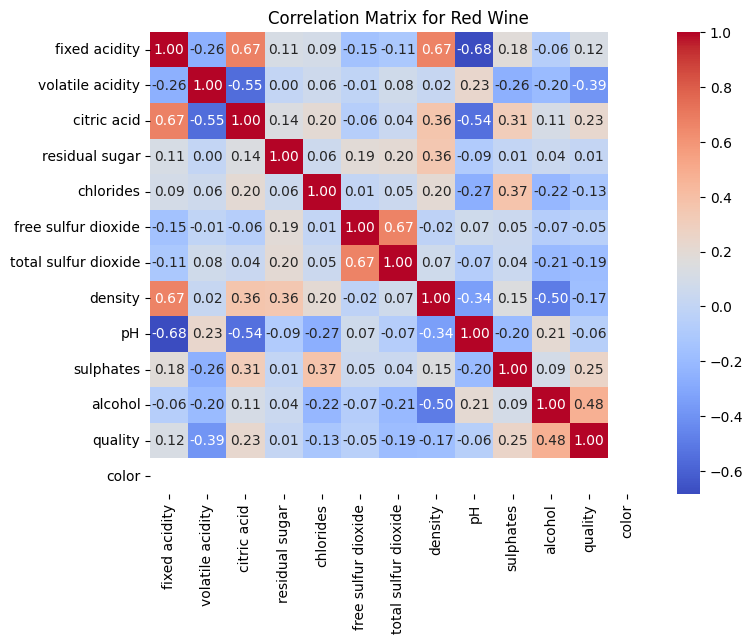

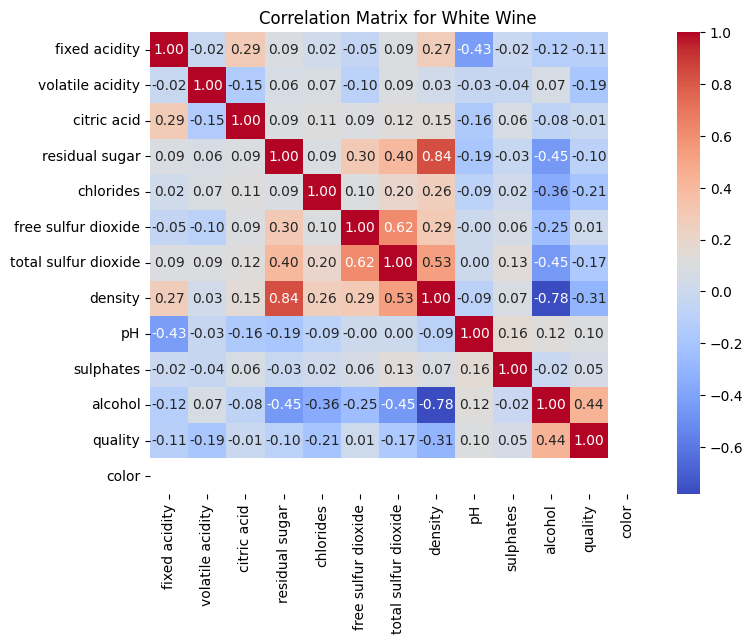

In [ ]:
# Load datasets
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')
# Add color column (0 for red, 1 for white)
red_wine['color'] = 0
white_wine['color'] = 1

# Combine datasets
wine_data = pd.concat([red_wine, white_wine], axis=0)

# Save merged data to CSV (optional)
wine_data.to_csv('wine_data.csv', index=False, sep=';')

# Display basic information
print("Data Loaded Successfully")
print(wine_data.head())
print(wine_data.describe())

# Correlation Matrices
plt.figure(figsize=(8, 6))
sns.heatmap(red_wine.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Red Wine')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(white_wine.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for White Wine')
plt.show()

The correlation matrices for red and white wines we get as the output of this part provide insight into the relationships between different physicochemical features. Positive correlation values indicate a direct relationship (as one feature increases, the other tends to increase), while negative values indicate an inverse relationship (as one feature increases, the other tends to decrease). The diagonal of the matrix represents the correlation of each feature with itself, which is always 1.

For example, in the case of white wines, alcohol content is negatively correlated with density, suggesting that higher alcohol content is associated with lower density. These matrices do not include correlation values for the color feature because it is a binary variable (0 for red and 1 for white), and such variables are not meaningful in this context.


# **Part 3 : Data Splitting and Preprocessing**

In this part, the dataset is divided into training and testing subsets to evaluate the model's performance on unseen data. Using an 80-20 split, 80% of the data is randomly sampled for training, and the remaining 20% is allocated for testing. The random_state=42 ensures reproducibility of the split.

The target variable (color) is separated from the input features. The training and testing data are further filtered to retain only a subset of important features, including volatile acidity, citric acid, residual sugar, density, sulphates, and alcohol. These features are selected based on their relevance to predicting the wine's color.

To standardize the data, the StandardScaler is applied to transform the input features so that they have a mean of 0 and a standard deviation of 1. This step ensures that all features are on a similar scale, which improves the stability and performance of the machine learning model.

Finally, the standardized training data is summarized using descriptive statistics to confirm that standardization has been applied correctly.



In [ ]:
# Data Splitting
train_data = wine_data.sample(frac=0.8, random_state=42)  # 80% training
test_data = wine_data.drop(train_data.index)  # 20% testing

x_train = train_data.drop(['color'], axis=1)
y_train = train_data['color']
x_test = test_data.drop(['color'], axis=1)
y_test = test_data['color']

# Select important features
selected_features = ['volatile acidity', 'citric acid', 'residual sugar', 'density', 'sulphates', 'alcohol']
x_train = x_train[selected_features]
x_test = x_test[selected_features]

# Standardize the data
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=selected_features)
x_test = pd.DataFrame(scaler.transform(x_test), columns=selected_features)

# Verify standardization
print("Training data after standardization:")
print(x_train.describe())

Training data after standardization:
       volatile acidity   citric acid  residual sugar       density  \
count      5.198000e+03  5.198000e+03    5.198000e+03  5.198000e+03   
mean       1.777040e-16  1.114068e-16   -8.543463e-17 -1.777109e-14   
std        1.000096e+00  1.000096e+00    1.000096e+00  1.000096e+00   
min       -1.588574e+00 -2.203887e+00   -1.029802e+00 -2.571250e+00   
25%       -6.755849e-01 -4.732669e-01   -7.752097e-01 -8.056341e-01   
50%       -3.103893e-01 -5.791816e-02   -5.206173e-01  5.860645e-02   
75%        4.200018e-01  4.958802e-01    5.614004e-01  7.675537e-01   
max        7.541316e+00  9.287429e+00    5.547168e+00  5.257553e+00   

          sulphates       alcohol  
count  5.198000e+03  5.198000e+03  
mean   4.312740e-16 -5.358460e-16  
std    1.000096e+00  1.000096e+00  
min   -2.004765e+00 -2.086041e+00  
25%   -6.832633e-01 -8.277999e-01  
50%   -1.546625e-01 -1.567377e-01  
75%    4.400134e-01  6.820900e-01  
max    9.690527e+00  3.701870e+00  

The dataset was split into 80% training and 20% testing subsets. The target variable color was separated from the input features. Six important features (volatile acidity, citric acid, residual sugar, density, sulphates, and alcohol) were selected for training and testing.

The features were standardized using StandardScaler, ensuring each has a mean of approximately 0 and a standard deviation of 1. This can be observed in the summary statistics of the training data: the mean for each feature is close to 0, and the standard deviation is nearly 1. Standardization ensures that all features are on the same scale, improving model performance and stability. The min, max, and quartile values confirm that the data has been effectively transformed for further analysis.


# **Part 4 : ANN Model Definition**

This section defines and trains an Artificial Neural Network (ANN) for binary classification, predicting whether a wine is red (0) or white (1).

**Model Definition**
The create_ann function defines the structure of the ANN:


*  **Input Layer** : Accepts input data with a shape corresponding to the number of selected features.

*   **Hidden Layers**:
*   The first hidden layer contains 64 neurons with the ReLU activation function.
*   The second hidden layer contains 32 neurons, also using the ReLU activation function.

*   **Output Layer**: A single neuron with a sigmoid activation function outputs a probability score for binary classification (0 or 1).


The model is compiled using:

* **Optimizer**: Adam, which is efficient for training deep learning models.

* **Loss Function**: binary_crossentropy, suitable for binary classification tasks.

* **Metrics**: accuracy, to track model performance during training.

**Model Training**

1. The ANN model is instantiated by calling create_ann with the number of selected features as the input shape.

2. A summary of the model structure is displayed, showing the layers and parameters.

3. The EarlyStopping callback is defined:
* Monitors the validation loss (val_loss).
* Stops training early if the validation loss does not improve for 15 consecutive epochs, helping to prevent overfitting.

4. The model is trained using the fit method:
* Inputs: The training data (x_train, y_train).
* Validation Data: The testing data (x_test, y_test) to evaluate performance during training.
* Epochs: Up to 300 iterations (with early stopping enabled).
* Batch Size: 25 samples per batch for gradient updates.
* Verbose: Displays training progress.
* Callback: Uses early stopping to halt training when validation loss stops improving.



In [ ]:
# ANN Model Definition
def create_ann(input_shape):
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and Train Model
ann_model = create_ann(len(selected_features))
ann_model.summary()

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)

history = ann_model.fit(
    x_train,
    y_train,
    epochs=300,
    batch_size=25,
    validation_data=(x_test, y_test),
    verbose=1,
    callbacks=[es]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8940 - loss: 0.3728 - val_accuracy: 0.9887 - val_loss: 0.0447
Epoch 2/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0733 - val_accuracy: 0.9937 - val_loss: 0.0247
Epoch 3/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9855 - loss: 0.0499 - val_accuracy: 0.9937 - val_loss: 0.0197
Epoch 4/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9892 - loss: 0.0426 - val_accuracy: 0.9937 - val_loss: 0.0238
Epoch 5/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9906 - loss: 0.0365 - val_accuracy: 0.9937 - val_loss: 0.0316
Epoch 6/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9872 - loss: 0.0463 - val_accuracy: 0.9950 - val_loss: 0.0341
Epoch 7/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9875 - loss: 0.0453 - val_accuracy: 0.9950 - val_loss: 0.0364
Epoch 8/300
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9905 - loss: 0.0358 - val_accu

After training, the model successfully learns to classify wines based on their physicochemical properties with high accuracy, as demonstrated by both the training and validation results. The training process utilized early stopping to prevent overfitting by monitoring validation loss. The history object captures key metrics such as accuracy and loss for both training and validation, which can be analyzed further to evaluate model performance and visualize its learning progression.


# **Part 5  : Model Evaluation and Performance Analysis**

This section evaluates the trained ANN model on the test data and provides insights into its performance. It calculates the overall accuracy, visualizes the training and validation history, and computes error metrics such as Mean Absolute Error (MAE) and R^2 for both the training and test datasets.




Test Accuracy: 0.99


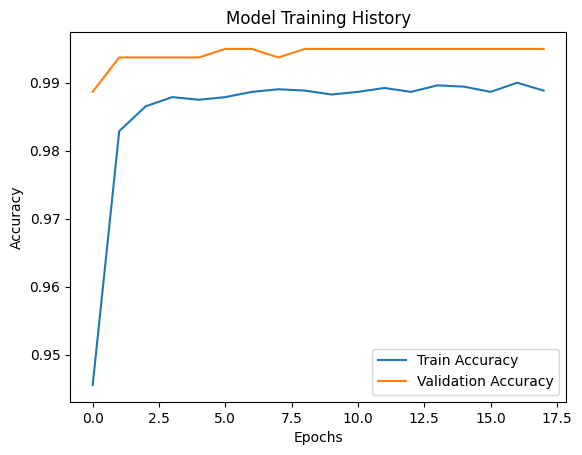

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Color(predicted) - Color(actual):
Train: mean: -0.00 std: 0.09 MAE: 0.02 R2: 0.98
Test: mean: -0.01 std: 0.07 MAE: 0.01 R2: 0.97


In [ ]:
# Evaluate Model
loss, accuracy = ann_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

# Plot Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Training History')
plt.show()

# Predictions and Error Metrics
ytrain_hat = ann_model.predict(x_train)
ytest_hat = ann_model.predict(x_test)

diffyt = ytrain_hat.flatten() - y_train.to_numpy()
diffyp = ytest_hat.flatten() - y_test.to_numpy()

print("\nColor(predicted) - Color(actual):")
print(
    "Train:",
    f"mean: {np.mean(diffyt):.2f}",
    f"std: {np.std(diffyt):.2f}",
    f"MAE: {np.mean(np.abs(diffyt)):.2f}",
    f"R2: {np.corrcoef(y_train.to_numpy(), ytrain_hat.flatten())[0, 1]:.2f}"
)
print(
    "Test:",
    f"mean: {np.mean(diffyp):.2f}",
    f"std: {np.std(diffyp):.2f}",
    f"MAE: {np.mean(np.abs(diffyp)):.2f}",
    f"R2: {np.corrcoef(y_test.to_numpy(), ytest_hat.flatten())[0, 1]:.2f}"
)


The model achieves a high accuracy on the test data, demonstrating its ability to classify wines effectively based on physicochemical features. Error metrics confirm strong alignment between predicted and actual values, with minimal differences, indicating a well-trained model. Additionally, the training history plot highlights consistent performance, validating the model's robustness.


# **Part 6 : Confusion Matrix**

In this section, confusion matrix is used to evaluate the model's performance in classifying red and white wines. The confusion matrix visually represents the number of correct and incorrect predictions for each class, providing a detailed breakdown of the model's classification acccuracy.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


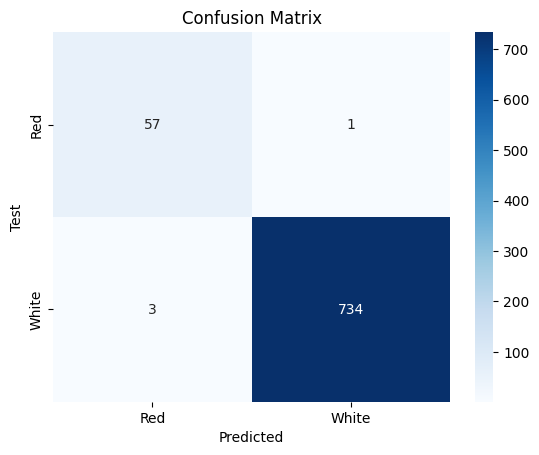

In [ ]:
# Confusion Matrix
y_pred = (ann_model.predict(x_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Red', 'White'], yticklabels=['Red', 'White'])
plt.xlabel('Predicted')
plt.ylabel('Test')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix demonstrates that the model accurately predicts a large majority of the samples for both red and white wines. This result confirms the model's effectiveness, considering the dataset contains more white wines than red, and the predictions are well-balanced.


# **Part 7 : K-Fold Cross Validation**

In this section K-Fold Cross-Validation is employed to evaluate the model's stability and generalization across different subsets of the training data. This approach ensures that the model is assessed on multiple training and validation splits, reducing bias and providing a robust estimate of its performance. Metrics such as Mean Absolute Error (MAE), R-squared (R²), and standard deviations are computed to analyze the consistency of the model.





In [ ]:
# K-Fold Cross-Validation

# Early stopping and model configuration
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)
VERBOSE = 1
EPOCHS = 300
BATCH_SIZE = 25
N_SPLIT = 5  # Number of splits

# Initialize metrics lists
meantT, stdtT, MAEtT, R2tT = [], [], [], []
meanvT, stdvT, MAEvT, R2vT = [], [], [], []

# K-Fold setup
kfold = KFold(n_splits=N_SPLIT, shuffle=True, random_state=42)

# K-Fold cross-validation loop
j = 0  # Fold counter
for train_idx, val_idx in list(kfold.split(x_train, y_train)):
    # Split into training and validation sets for the current fold
    x_train_cv = x_train.iloc[train_idx]
    y_train_cv = y_train.iloc[train_idx]
    x_valid_cv = x_train.iloc[val_idx]
    y_valid_cv = y_train.iloc[val_idx]

    # Scale the training and validation data
    scaler = preprocessing.StandardScaler()
    x_train_cv_scaled = scaler.fit_transform(x_train_cv.values)
    x_valid_cv_scaled = scaler.transform(x_valid_cv.values)

    # Convert scaled arrays back to DataFrames
    x_train_cv = pd.DataFrame(x_train_cv_scaled, index=x_train_cv.index, columns=x_train_cv.columns)
    x_valid_cv = pd.DataFrame(x_valid_cv_scaled, index=x_valid_cv.index, columns=x_valid_cv.columns)

    print(f"\nFold {j + 1}")
    j += 1  # Increment fold counter

    # Create and train the ANN model
    ANNmodel = create_ann(len(selected_features))
    ANNhistory = ANNmodel.fit(
        x_train_cv,
        y_train_cv,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=VERBOSE,
        validation_data=(x_valid_cv, y_valid_cv),
        callbacks=[es]
    )

    # Predictions for training and validation sets
    ytrain_hat = ANNmodel.predict(x_train_cv)
    yvalid_hat = ANNmodel.predict(x_valid_cv)

    # Calculate errors and metrics
    diffyt = ytrain_hat.flatten() - y_train_cv.to_numpy()
    diffyv = yvalid_hat.flatten() - y_valid_cv.to_numpy()

    print("Color (predicted) - Color (actual):")
    print(
        "Train:",
        f"mean: {np.mean(diffyt):.2f}",
        f"std: {np.std(diffyt):.2f}",
        f"MAE: {np.mean(np.abs(diffyt)):.2f}",
        f"R2: {np.corrcoef(y_train_cv.to_numpy(), ytrain_hat.flatten())[0, 1]:.2f}"
    )
    print(
        "Validation:",
        f"mean: {np.mean(diffyv):.2f}",
        f"std: {np.std(diffyv):.2f}",
        f"MAE: {np.mean(np.abs(diffyv)):.2f}",
        f"R2: {np.corrcoef(y_valid_cv.to_numpy(), yvalid_hat.flatten())[0, 1]:.2f}"
    )

    # Append metrics for each fold
    meantT.append(np.mean(diffyt))
    meanvT.append(np.mean(diffyv))
    stdtT.append(np.std(diffyt))
    stdvT.append(np.std(diffyv))
    MAEtT.append(np.mean(np.abs(diffyt)))
    MAEvT.append(np.mean(np.abs(diffyv)))
    R2tT.append(np.corrcoef(y_train_cv.to_numpy(), ytrain_hat.flatten())[0, 1])
    R2vT.append(np.corrcoef(y_valid_cv.to_numpy(), yvalid_hat.flatten())[0, 1])

# Print average metrics across folds
print("\nSummary of Cross-Validation Metrics:")
print(f"Average MAE for training set: {np.mean(MAEtT):.2f} +/- {np.std(MAEtT):.2f}")
print(f"Average MAE for validation set: {np.mean(MAEvT):.2f} +/- {np.std(MAEvT):.2f}")



Fold 1
Epoch 1/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9074 - loss: 0.3510 - val_accuracy: 0.9644 - val_loss: 0.1011
Epoch 2/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9739 - loss: 0.0791 - val_accuracy: 0.9769 - val_loss: 0.0748
Epoch 3/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9832 - loss: 0.0468 - val_accuracy: 0.9750 - val_loss: 0.0721
Epoch 4/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9886 - loss: 0.0446 - val_accuracy: 0.9798 - val_loss: 0.0731
Epoch 5/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0420 - val_accuracy: 0.9808 - val_loss: 0.0706
Epoch 6/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9912 - loss: 0.0339 - val_accuracy: 0.9798 - val_loss: 0.0735
Epoch 7/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9942 - loss: 0.0290 - val_accuracy: 0.9779 - val_loss: 0.0749
Epoch 8/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9897 - loss: 0.0366 - 

The output shows the model's performance across folds. The training set metrics demonstrate how well the model fits the data, while the validation set metrics reflect the model's ability to generalize to unseen data. Consistently low MAE and high R^2 values indicate that the model effectively predicts wine color based on the selected physicochemical features.

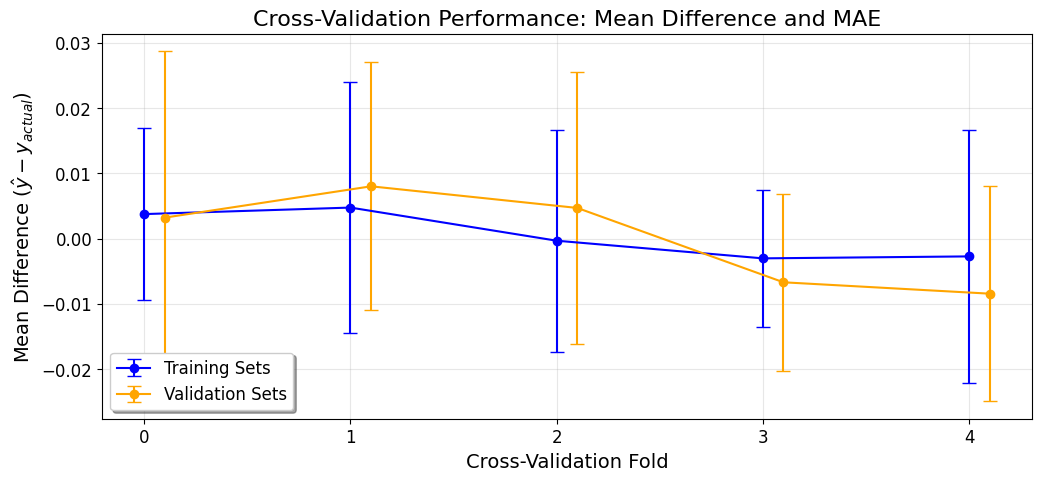

In [ ]:
# Plot Cross-Validation Results
fig_cv, ax_cv = plt.subplots(figsize=(12, 5))

# Plot training metrics with error bars
ax_cv.errorbar(
    x=np.arange(len(meantT)),
    y=meantT,
    yerr=MAEtT,
    label='Training Sets',
    fmt='o-',
    capsize=5,
    color='blue'
)

# Plot validation metrics with error bars
ax_cv.errorbar(
    x=np.arange(len(meanvT)) + 0.1,  # Slight offset for visibility
    y=meanvT,
    yerr=MAEvT,
    label='Validation Sets',
    fmt='o-',
    capsize=5,
    color='orange'
)

# Add legend, labels, and formatting
ax_cv.legend(loc='lower left', shadow=True, fontsize=12)
ax_cv.set_xlabel('Cross-Validation Fold', fontdict={'fontsize': 14})
ax_cv.set_ylabel('Mean Difference ($\hat{y} - y_{actual}$)', fontdict={'fontsize': 14})
ax_cv.tick_params(labelsize=12)

# Show the plot
plt.title("Cross-Validation Performance: Mean Difference and MAE", fontsize=16)
plt.grid(alpha=0.3)
plt.show()



The graph visualizes the mean differences and MAE for both the training and validation sets across folds. The close alignment of training and validation metrics indicates the model's stability and lack of overfitting.


# **Part 8 : SHAP Analysis**

In this section, SHAP ( SHapley Additive exPlanations) is used to interpret the model's predictions and understand the contribution of each feature to the classification of wines. The KernelExplainer is employed with a subset of training data as the background and another subset for the analysis to improve efficiency. SHAP values quantify the impact of each feature on the model's predictions.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
388/388 ━━━━━

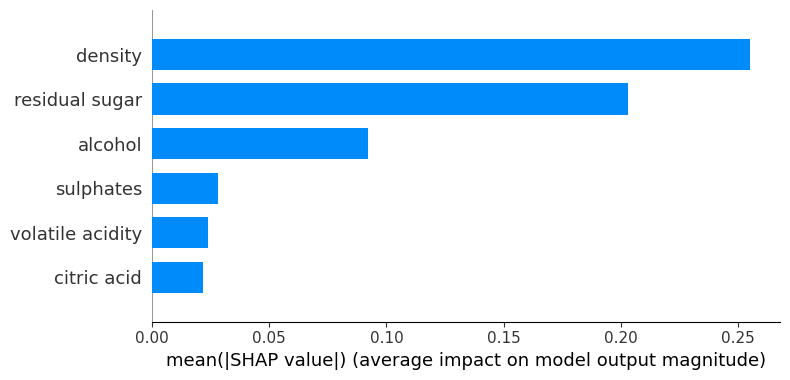

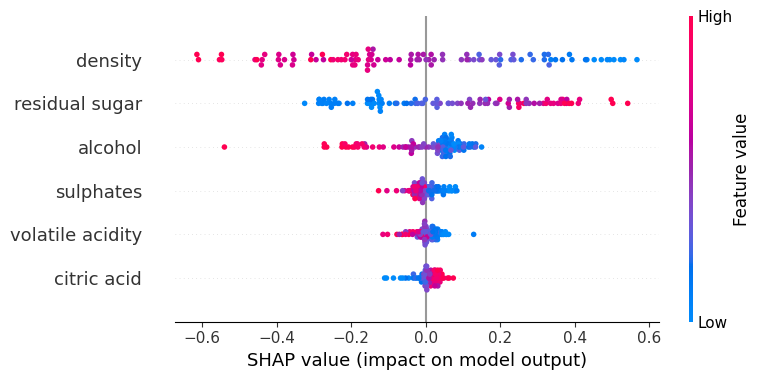

In [ ]:
# SHAP Analysis using KernelExplainer
import shap

# Sample a subset of the training data as the background for SHAP
background = x_train.sample(200, random_state=42)  # SHAP background data
x_sample = x_train.sample(100, random_state=42)  # Smaller subset for explanation to save time

# Initialize KernelExplainer with the model's predict function
explainer = shap.KernelExplainer(ann_model.predict, background)

# Compute SHAP values for the subset
shap_values = explainer.shap_values(x_sample, nsamples=100)

# Handle SHAP values for binary classification
if isinstance(shap_values, list):  # For binary classification, shap_values is a list
    shap_values_class = shap_values[0]  # Use the SHAP values for the first output class
else:
    shap_values_class = shap_values  # Use directly if it's not a list

# Convert x_sample back to DataFrame for compatibility
x_sample_df = pd.DataFrame(x_sample, columns=selected_features)

# Reshape shap_values_class to match x_sample_df
# by removing the extra dimension for the output class
shap_values_class = shap_values_class.reshape(shap_values_class.shape[0], shap_values_class.shape[1])

print(f"SHAP values shape: {shap_values_class.shape}")  # Should match x_sample's shape
print(f"x_sample_df shape: {x_sample_df.shape}")

# Validate shapes (This should now pass without error)
if shap_values_class.shape != x_sample_df.shape:
    raise ValueError(f"Shape mismatch: shap_values_class {shap_values_class.shape} does not match x_sample_df {x_sample_df.shape}")

# Plot summary
shap.summary_plot(shap_values_class, x_sample_df, feature_names=selected_features, plot_type="bar")
shap.summary_plot(shap_values_class, x_sample_df, feature_names=selected_features)

The SHAP analysis highlights the importance of individual features in predicting wine color. The summary plot visually ranks features by their average contribution, showing which attributes (e.g., density or alcohol) are most influential in the classification. This adds explainability to the model, ensuring transparency and providing insights into the physicochemical properties driving the predictions.

# **Conclusion**

This project successfully classified Portuguese Vinho Verde wines (red or white) using their physicochemical properties. Key steps included:

1. **Data Preparation**: Red and white wine datasets were combined, preprocessed, and standardized, with correlation matrices providing feature insights.

2. **Model Development**: A neural network achieved high accuracy in classifying wines based on selected features.

3. **Evaluation**: The model performed well on the test set, confirmed by metrics like MAE, R², and a confusion matrix.

4. **Cross-Validation**: Cross-validation ensured the model's stability and reliability.

5. **Interpretability**: SHAP analysis highlighted feature importance, enhancing model transparency.

**Outcome**: The model is accurate, robust, and interpretable, offering valuable insights into the dataset and providing a reliable pipeline for similar classification tasks.

